# Reference Card Extraction

This notebook is fully self-contained: all extraction and visualization code is defined here.
Run the cells from top to bottom, then tune hyperparameters and rerun only the lower execution cells as needed.

In [1]:
from dataclasses import dataclass
from math import ceil
from pathlib import Path

import cv2
import numpy as np
from PIL import Image

PROJECT_ROOT = Path.cwd().resolve().parent
while not (PROJECT_ROOT / "data").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

REFERENCE_IMAGES_DIR = PROJECT_ROOT / "data" / "iapr-26-uno-vision-challenge" / "reference_images"
REFERENCE_CARDS_DIR = PROJECT_ROOT / "project" / "training_data" / "training_images" / "reference_cards"

if not REFERENCE_IMAGES_DIR.exists():
    raise FileNotFoundError(f"Reference image directory not found: {REFERENCE_IMAGES_DIR}")

REFERENCE_CARDS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Reference images: {REFERENCE_IMAGES_DIR}")
print(f"Processed outputs: {REFERENCE_CARDS_DIR}")

Project root: /Users/dorianbesson/EDOC/IA/iapr2026do
Reference images: /Users/dorianbesson/EDOC/IA/iapr2026do/data/iapr-26-uno-vision-challenge/reference_images
Processed outputs: /Users/dorianbesson/EDOC/IA/iapr2026do/project/training_data/training_images/reference_cards


## Core Functions

The next cell defines all extraction and visualization utilities used by this notebook.

In [2]:
@dataclass(frozen=True)
class ReferenceExtractionResult:
    # Paths created for one reference image.
    image_name: str
    output_dir: Path
    crops: list[Path]
    masks: list[Path]
    components: list[Path]


# Load one reference image as grayscale + RGB.
def load_reference_image(
    image_name: str,
    image_dir: Path = REFERENCE_IMAGES_DIR,
) -> tuple[np.ndarray, np.ndarray]:
    image_path = image_dir / f"{image_name}.jpg"
    gray = np.array(Image.open(image_path).convert("L"))
    color_bgr = cv2.imread(str(image_path))
    if color_bgr is None:
        raise FileNotFoundError(f"Cannot read reference image: {image_path}")
    return gray, cv2.cvtColor(color_bgr, cv2.COLOR_BGR2RGB)


# OpenCV kernels here must be odd.
def _odd(value: float) -> int:
    v = max(3, int(value))
    return v if v % 2 == 1 else v + 1


# Normalize OpenCV rotated rectangles to long-side-first representation.
def _normalize_rotated_rect(
    rect: tuple[tuple[float, float], tuple[float, float], float],
) -> tuple[tuple[float, float], tuple[float, float], float]:
    (cx, cy), (rw, rh), angle = rect
    rw_f, rh_f, angle_f = float(rw), float(rh), float(angle)
    if rw_f < rh_f:
        rw_f, rh_f = rh_f, rw_f
        angle_f -= 90.0
    return ((float(cx), float(cy)), (rw_f, rh_f), angle_f)


# Build a rounded rectangle mask, optionally rotated and placed on a full canvas.
def _rounded_rotated_rect_mask(
    shape: tuple[int, int],
    rect: tuple[tuple[float, float], tuple[float, float], float],
    rounded_corner_ratio: float,
    fixed_card_width: int | None = None,
    fixed_card_height: int | None = None,
) -> np.ndarray:
    h, w = shape
    (cx, cy), (rw, rh), angle = _normalize_rotated_rect(rect)

    if fixed_card_width is not None and fixed_card_height is not None:
        fw = max(1, int(round(fixed_card_width)))
        fh = max(1, int(round(fixed_card_height)))
        rw, rh = float(max(fw, fh)), float(min(fw, fh))

    rw_i, rh_i = int(np.ceil(rw)), int(np.ceil(rh))
    if rw_i <= 0 or rh_i <= 0:
        return np.zeros((h, w), dtype=np.uint8)

    corner_radius = int(round(min(rh_i, rw_i) * rounded_corner_ratio))
    corner_radius = min(max(corner_radius, 0), (min(rh_i, rw_i) - 1) // 2)

    local_mask = np.zeros((rh_i, rw_i), dtype=np.uint8)
    if corner_radius <= 0:
        local_mask[:, :] = 255
    else:
        cv2.rectangle(local_mask, (corner_radius, 0), (rw_i - corner_radius - 1, rh_i - 1), 255, thickness=-1)
        cv2.rectangle(local_mask, (0, corner_radius), (rw_i - 1, rh_i - corner_radius - 1), 255, thickness=-1)
        cv2.circle(local_mask, (corner_radius, corner_radius), corner_radius, 255, thickness=-1)
        cv2.circle(local_mask, (rw_i - corner_radius - 1, corner_radius), corner_radius, 255, thickness=-1)
        cv2.circle(local_mask, (corner_radius, rh_i - corner_radius - 1), corner_radius, 255, thickness=-1)
        cv2.circle(local_mask, (rw_i - corner_radius - 1, rh_i - corner_radius - 1), corner_radius, 255, thickness=-1)

    canvas = np.zeros((h, w), dtype=np.uint8)
    x0 = int(round(cx - rw / 2))
    y0 = int(round(cy - rh / 2))
    x1 = x0 + rw_i
    y1 = y0 + rh_i

    dst_x0 = max(0, x0)
    dst_y0 = max(0, y0)
    dst_x1 = min(w, x1)
    dst_y1 = min(h, y1)
    if dst_x1 <= dst_x0 or dst_y1 <= dst_y0:
        return canvas

    src_x0 = dst_x0 - x0
    src_y0 = dst_y0 - y0
    src_x1 = src_x0 + (dst_x1 - dst_x0)
    src_y1 = src_y0 + (dst_y1 - dst_y0)
    canvas[dst_y0:dst_y1, dst_x0:dst_x1] = local_mask[src_y0:src_y1, src_x0:src_x1]

    M = cv2.getRotationMatrix2D((cx, cy), angle, 1.0)
    return cv2.warpAffine(
        canvas,
        cv2.invertAffineTransform(M),
        (w, h),
        flags=cv2.INTER_NEAREST,
        borderValue=0,
    )


# Remove tiny residual blobs.
def _remove_small_contours(mask: np.ndarray, min_area_abs: int) -> np.ndarray:
    out = mask.copy()
    contours, _ = cv2.findContours(out, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for c in contours:
        if cv2.contourArea(c) < min_area_abs:
            cv2.drawContours(out, [c], -1, 0, cv2.FILLED)
    return out


# Shared mask pipeline so debug plots and extraction stay aligned.
def _mask_pipeline_core(
    gray: np.ndarray,
    adaptive_block_size: int,
    adaptive_c: int,
    pre_blur_size: int,
    dilate_size_1: int,
    clean_mask_min_area_abs: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    adaptive_image = cv2.adaptiveThreshold(
        gray,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        blockSize=_odd(adaptive_block_size),
        C=adaptive_c,
    )
    median_filtered = cv2.medianBlur(adaptive_image, _odd(pre_blur_size))
    binary = cv2.bitwise_not(median_filtered) if np.mean(median_filtered == 255) > 0.5 else median_filtered

    kernel1 = np.ones((dilate_size_1, dilate_size_1), np.uint8)
    dilated1 = cv2.morphologyEx(binary, cv2.MORPH_DILATE, kernel1)
    clean_mask = _remove_small_contours(dilated1, clean_mask_min_area_abs)
    return adaptive_image, median_filtered, dilated1, clean_mask


# Border/interior support score for one fixed-size rectangle hypothesis.
def _score_fixed_rect_hypothesis(
    mask: np.ndarray,
    rect: tuple[tuple[float, float], tuple[float, float], float],
    rounded_corner_ratio: float = 0.08,
    border_thickness: int = 6,
    interior_weight: float = 0.3,
) -> tuple[float, float, float]:
    rect_norm = _normalize_rotated_rect(rect)
    (cx, cy), (rw, rh), angle = rect_norm
    box = cv2.boxPoints(rect_norm)
    margin = max(2, int(np.ceil(max(2.0 * border_thickness, min(rw, rh) * rounded_corner_ratio))) + 2)

    x0 = max(0, int(np.floor(np.min(box[:, 0]))) - margin)
    y0 = max(0, int(np.floor(np.min(box[:, 1]))) - margin)
    x1 = min(mask.shape[1], int(np.ceil(np.max(box[:, 0]))) + margin)
    y1 = min(mask.shape[0], int(np.ceil(np.max(box[:, 1]))) + margin)
    if x1 <= x0 or y1 <= y0:
        return 0.0, 0.0, 0.0

    roi = mask[y0:y1, x0:x1]
    local_rect = ((cx - x0, cy - y0), (rw, rh), angle)
    filled = _rounded_rotated_rect_mask(roi.shape, local_rect, rounded_corner_ratio)
    if np.count_nonzero(filled) == 0:
        return 0.0, 0.0, 0.0

    k = max(1, int(round(border_thickness)))
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * k + 1, 2 * k + 1))
    inner = cv2.erode(filled, kernel, iterations=1)
    border = cv2.subtract(filled, inner)

    support = roi > 0
    border_idx = border > 0
    if not np.any(border_idx):
        return 0.0, 0.0, 0.0

    border_support = float(np.mean(support[border_idx]))
    inner_idx = inner > 0
    interior_support = float(np.mean(support[inner_idx])) if np.any(inner_idx) else border_support

    w = float(np.clip(interior_weight, 0.0, 1.0))
    score = (1.0 - w) * border_support + w * interior_support
    return score, border_support, interior_support


# IoU between two rotated rectangles for NMS.
def _rotated_rect_iou(
    rect_a: tuple[tuple[float, float], tuple[float, float], float],
    rect_b: tuple[tuple[float, float], tuple[float, float], float],
) -> float:
    a = _normalize_rotated_rect(rect_a)
    b = _normalize_rotated_rect(rect_b)
    area_a = float(a[1][0] * a[1][1])
    area_b = float(b[1][0] * b[1][1])
    if area_a <= 0.0 or area_b <= 0.0:
        return 0.0

    _, inter_pts = cv2.rotatedRectangleIntersection(a, b)
    if inter_pts is None:
        return 0.0

    inter_area = float(abs(cv2.contourArea(inter_pts)))
    union = area_a + area_b - inter_area
    return inter_area / union if union > 0.0 else 0.0


# Generate and score fixed-size rectangle hypotheses from fragmented components.
def _detect_fixed_rect_hypotheses(
    mask: np.ndarray,
    card_width: int,
    card_height: int,
    center_shift_fraction: float = 0.1,
    angle_jitter_deg: float = 2.0,
    angle_jitter_step_deg: float = 1.0,
    rounded_corner_ratio: float = 0.08,
    border_thickness: int = 6,
    interior_weight: float = 0.3,
    min_border_support: float = 0.45,
    min_score: float = 0.28,
    nms_iou: float = 0.35,
    max_keep: int | None = None,
    max_candidates: int = 8000,
) -> list[dict[str, object]]:
    card_long = float(max(int(round(card_width)), int(round(card_height))))
    card_short = float(min(int(round(card_width)), int(round(card_height))))
    if card_long <= 1.0 or card_short <= 1.0:
        return []

    # Internal noise gate: fixed ratio of target card area.
    min_fragment_area_abs = max(120, int(0.003 * card_long * card_short))

    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)

    shift = max(0.0, float(center_shift_fraction))
    if shift > 0.0:
        shift_pairs = [
            (0.0, 0.0),
            (-shift, 0.0),
            (shift, 0.0),
            (0.0, -shift),
            (0.0, shift),
        ]
    else:
        shift_pairs = [(0.0, 0.0)]

    jitter = max(0.0, float(angle_jitter_deg))
    if jitter > 0.0:
        step = max(0.5, float(angle_jitter_step_deg))
        offsets = list(np.arange(-jitter, jitter + 0.5 * step, step))
    else:
        offsets = [0.0]

    candidate_limit = max(1, int(max_candidates))
    candidates: list[tuple[tuple[float, float], tuple[float, float], float]] = []
    seen: set[tuple[int, int, int]] = set()

    for lbl in range(1, n_labels):
        if int(stats[lbl, cv2.CC_STAT_AREA]) < min_fragment_area_abs:
            continue

        fragment = np.zeros_like(mask)
        fragment[labels == lbl] = 255
        contours, _ = cv2.findContours(fragment, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            continue

        ((cx, cy), _, base_angle) = _normalize_rotated_rect(cv2.minAreaRect(np.vstack(contours)))

        for d_angle in offsets:
            angle = float(base_angle + d_angle)
            theta = np.deg2rad(angle)
            axis_long = np.array([np.cos(theta), np.sin(theta)], dtype=np.float32)
            axis_short = np.array([-np.sin(theta), np.cos(theta)], dtype=np.float32)

            for s_long, s_short in shift_pairs:
                center = np.array([cx, cy], dtype=np.float32)
                center += axis_long * (s_long * 0.5 * card_long)
                center += axis_short * (s_short * 0.5 * card_short)
                c_x, c_y = float(center[0]), float(center[1])

                key = (
                    int(round(c_x / 2.0)),
                    int(round(c_y / 2.0)),
                    int(round((angle % 180.0) * 2.0)),
                )
                if key in seen:
                    continue
                seen.add(key)
                candidates.append(((c_x, c_y), (card_long, card_short), angle))

                if len(candidates) >= candidate_limit:
                    break
            if len(candidates) >= candidate_limit:
                break
        if len(candidates) >= candidate_limit:
            break

    scored: list[dict[str, object]] = []
    for rect in candidates:
        score, border_support, interior_support = _score_fixed_rect_hypothesis(
            mask,
            rect,
            rounded_corner_ratio=rounded_corner_ratio,
            border_thickness=border_thickness,
            interior_weight=interior_weight,
        )
        if border_support < float(min_border_support) or score < float(min_score):
            continue

        scored.append(
            {
                "rect": _normalize_rotated_rect(rect),
                "score": float(score),
                "border_support": float(border_support),
                "interior_support": float(interior_support),
            }
        )

    scored.sort(key=lambda d: float(d["score"]), reverse=True)

    selected: list[dict[str, object]] = []
    for candidate in scored:
        rect = candidate["rect"]
        if any(_rotated_rect_iou(rect, keep["rect"]) >= float(nms_iou) for keep in selected):
            continue
        selected.append(candidate)
        if max_keep is not None and len(selected) >= max_keep:
            break

    return selected


# Shared wrapper for fixed-size hypothesis generation in both preview and extraction.
def _run_fixed_size_hypotheses(
    clean_mask: np.ndarray,
    filter_card_width: int | None,
    filter_card_height: int | None,
    hypothesis_center_shift_fraction: float = 0.1,
    hypothesis_angle_jitter_deg: float = 2.0,
    hypothesis_angle_jitter_step_deg: float = 1.0,
    hypothesis_border_thickness: int = 6,
    hypothesis_interior_weight: float = 0.3,
    hypothesis_min_border_support: float = 0.45,
    hypothesis_min_score: float = 0.28,
    hypothesis_nms_iou: float = 0.35,
    hypothesis_max_candidates: int = 8000,
    rounded_corner_ratio: float = 0.08,
    max_keep: int | None = None,
) -> list[dict[str, object]]:
    if filter_card_width is None or filter_card_height is None:
        raise ValueError("Fixed card width/height must be provided (AR fallback removed).")

    return _detect_fixed_rect_hypotheses(
        clean_mask,
        card_width=int(round(filter_card_width)),
        card_height=int(round(filter_card_height)),
        center_shift_fraction=hypothesis_center_shift_fraction,
        angle_jitter_deg=hypothesis_angle_jitter_deg,
        angle_jitter_step_deg=hypothesis_angle_jitter_step_deg,
        rounded_corner_ratio=rounded_corner_ratio,
        border_thickness=hypothesis_border_thickness,
        interior_weight=hypothesis_interior_weight,
        min_border_support=hypothesis_min_border_support,
        min_score=hypothesis_min_score,
        nms_iou=hypothesis_nms_iou,
        max_keep=max_keep,
        max_candidates=hypothesis_max_candidates,
    )


# Draw selected hypotheses for visualization.
def _render_hypothesis_overlay(
    shape: tuple[int, int],
    hypotheses: list[dict[str, object]],
) -> np.ndarray:
    h, w = shape
    overlay = np.zeros((h, w, 3), dtype=np.uint8)
    for hypothesis in hypotheses:
        rect = hypothesis["rect"]
        score = float(hypothesis["score"])
        box = cv2.boxPoints(rect).astype(np.int32)
        g = int(np.clip(70 + 185 * score, 0, 255))
        cv2.polylines(overlay, [box], True, (20, g, 255 - g), 2, lineType=cv2.LINE_AA)
    return overlay


# Keep intermediate masks for tuning visualization.
def _mask_pipeline_steps(
    gray: np.ndarray,
    adaptive_block_size: int = 11,
    adaptive_c: int = 4,
    pre_blur_size: int = 3,
    dilate_size_1: int = 17,
    clean_mask_min_area_abs: int = 2000,
    filter_card_width: int | None = 372,
    filter_card_height: int | None = 561,
    hypothesis_center_shift_fraction: float = 0.1,
    hypothesis_angle_jitter_deg: float = 2.0,
    hypothesis_angle_jitter_step_deg: float = 1.0,
    hypothesis_border_thickness: int = 6,
    hypothesis_interior_weight: float = 0.3,
    hypothesis_min_border_support: float = 0.45,
    hypothesis_min_score: float = 0.28,
    hypothesis_nms_iou: float = 0.35,
    hypothesis_max_candidates: int = 8000,
    rounded_corner_ratio: float = 0.08,
) -> dict[str, np.ndarray]:
    adaptive_image, median_filtered, dilated1, clean_mask = _mask_pipeline_core(
        gray,
        adaptive_block_size,
        adaptive_c,
        pre_blur_size,
        dilate_size_1,
        clean_mask_min_area_abs,
    )

    hypotheses = _run_fixed_size_hypotheses(
        clean_mask,
        filter_card_width=filter_card_width,
        filter_card_height=filter_card_height,
        hypothesis_center_shift_fraction=hypothesis_center_shift_fraction,
        hypothesis_angle_jitter_deg=hypothesis_angle_jitter_deg,
        hypothesis_angle_jitter_step_deg=hypothesis_angle_jitter_step_deg,
        hypothesis_border_thickness=hypothesis_border_thickness,
        hypothesis_interior_weight=hypothesis_interior_weight,
        hypothesis_min_border_support=hypothesis_min_border_support,
        hypothesis_min_score=hypothesis_min_score,
        hypothesis_nms_iou=hypothesis_nms_iou,
        hypothesis_max_candidates=hypothesis_max_candidates,
        rounded_corner_ratio=rounded_corner_ratio,
        max_keep=None,
    )
    overlay = _render_hypothesis_overlay(clean_mask.shape, hypotheses)

    return {
        "1 - Adaptive threshold [block/C]": adaptive_image,
        "2 - Median filter [pre_blur_size]": median_filtered,
        "3 - Invert + Dilate [dilate_size_1]": dilated1,
        "4 - Clean mask [clean_mask_min_area_abs]": clean_mask,
        "5 - Rectangle hypotheses [fixed-size scoring + NMS]": overlay,
    }


# Main extraction: components + closed components + crop masks + crops.
def extract_reference_card_assets(
    image_name: str,
    num_components: int,
    image_dir: Path = REFERENCE_IMAGES_DIR,
    output_root: Path = REFERENCE_CARDS_DIR,
    adaptive_block_size: int = 11,
    adaptive_c: int = 4,
    pre_blur_size: int = 3,
    dilate_size_1: int = 17,
    clean_mask_min_area_abs: int = 2000,
    filter_card_width: int | None = 372,
    filter_card_height: int | None = 561,
    hypothesis_center_shift_fraction: float = 0.1,
    hypothesis_angle_jitter_deg: float = 2.0,
    hypothesis_angle_jitter_step_deg: float = 1.0,
    hypothesis_border_thickness: int = 6,
    hypothesis_interior_weight: float = 0.3,
    hypothesis_min_border_support: float = 0.45,
    hypothesis_min_score: float = 0.28,
    hypothesis_nms_iou: float = 0.35,
    hypothesis_max_candidates: int = 8000,
    fixed_card_width: int | None = None,
    fixed_card_height: int | None = None,
    rounded_corner_ratio: float = 0.08,
) -> ReferenceExtractionResult:
    image_path = image_dir / f"{image_name}.jpg"
    gray = np.array(Image.open(image_path).convert("L"))
    img_color = cv2.imread(str(image_path))
    if img_color is None:
        raise FileNotFoundError(f"Cannot read reference image: {image_path}")

    out_dir = output_root / image_name
    components_dir = out_dir / "components"
    closed_dir = out_dir / "closed_components"
    masks_dir = out_dir / "masks"
    crops_dir = out_dir / "crops"
    for directory in (components_dir, closed_dir, masks_dir, crops_dir):
        directory.mkdir(parents=True, exist_ok=True)
        for f in directory.glob("*.jpg"):
            f.unlink()

    _, _, _, clean_mask = _mask_pipeline_core(
        gray,
        adaptive_block_size,
        adaptive_c,
        pre_blur_size,
        dilate_size_1,
        clean_mask_min_area_abs,
    )
    if np.count_nonzero(clean_mask) == 0:
        return ReferenceExtractionResult(image_name, out_dir, [], [], [])

    hypotheses = _run_fixed_size_hypotheses(
        clean_mask,
        filter_card_width=filter_card_width,
        filter_card_height=filter_card_height,
        hypothesis_center_shift_fraction=hypothesis_center_shift_fraction,
        hypothesis_angle_jitter_deg=hypothesis_angle_jitter_deg,
        hypothesis_angle_jitter_step_deg=hypothesis_angle_jitter_step_deg,
        hypothesis_border_thickness=hypothesis_border_thickness,
        hypothesis_interior_weight=hypothesis_interior_weight,
        hypothesis_min_border_support=hypothesis_min_border_support,
        hypothesis_min_score=hypothesis_min_score,
        hypothesis_nms_iou=hypothesis_nms_iou,
        hypothesis_max_candidates=hypothesis_max_candidates,
        rounded_corner_ratio=rounded_corner_ratio,
        max_keep=num_components,
    )
    if not hypotheses:
        return ReferenceExtractionResult(image_name, out_dir, [], [], [])

    # Optional global card size to enforce consistent crops.
    fixed_long: float | None = None
    fixed_short: float | None = None
    if fixed_card_width is not None and fixed_card_height is not None:
        fw = max(1, int(round(fixed_card_width)))
        fh = max(1, int(round(fixed_card_height)))
        fixed_long = float(max(fw, fh))
        fixed_short = float(min(fw, fh))

    crops: list[Path] = []
    crop_masks: list[Path] = []
    components: list[Path] = []

    for plot_i, hypothesis in enumerate(hypotheses):
        rect = hypothesis["rect"]

        rect_mask = _rounded_rotated_rect_mask(clean_mask.shape, rect, rounded_corner_ratio)
        observed = cv2.bitwise_and(clean_mask, rect_mask)
        component_mask = observed if np.any(observed) else rect_mask

        component_path = components_dir / f"component_{plot_i}.jpg"
        cv2.imwrite(str(component_path), component_mask)
        components.append(component_path)

        ((cx, cy), (rw, rh), angle) = _normalize_rotated_rect(rect)
        if fixed_long is not None and fixed_short is not None:
            rw, rh = fixed_long, fixed_short

        closed_component_mask = _rounded_rotated_rect_mask(
            component_mask.shape,
            ((cx, cy), (rw, rh), angle),
            rounded_corner_ratio,
        )
        closed_component_path = closed_dir / f"closed_component_{plot_i}.jpg"
        cv2.imwrite(str(closed_component_path), closed_component_mask)

        rw_i, rh_i = int(np.ceil(rw)), int(np.ceil(rh))
        M = cv2.getRotationMatrix2D((cx, cy), angle, 1.0)
        warped_img = cv2.warpAffine(
            img_color,
            M,
            (img_color.shape[1], img_color.shape[0]),
            borderValue=(255, 255, 255),
        )

        x0 = int(round(cx - rw / 2))
        y0 = int(round(cy - rh / 2))
        x1 = x0 + rw_i
        y1 = y0 + rh_i

        x0 = max(0, x0)
        y0 = max(0, y0)
        x1 = min(warped_img.shape[1], x1)
        y1 = min(warped_img.shape[0], y1)

        crop_color = warped_img[y0:y1, x0:x1]
        if crop_color.size == 0:
            continue

        crop_h, crop_w = crop_color.shape[:2]
        crop_mask_tight = _rounded_rotated_rect_mask(
            (crop_h, crop_w),
            ((crop_w / 2.0, crop_h / 2.0), (float(crop_w), float(crop_h)), 0.0),
            rounded_corner_ratio,
        )

        # Keep portrait orientation for downstream consistency.
        if crop_w > crop_h:
            crop_color = cv2.rotate(crop_color, cv2.ROTATE_90_CLOCKWISE)
            crop_mask_tight = cv2.rotate(crop_mask_tight, cv2.ROTATE_90_CLOCKWISE)

        mask_path = masks_dir / f"mask_{plot_i}.jpg"
        cv2.imwrite(str(mask_path), crop_mask_tight)
        crop_masks.append(mask_path)

        crop_path = crops_dir / f"crop_{plot_i}.jpg"
        cv2.imwrite(str(crop_path), crop_color)
        crops.append(crop_path)

    return ReferenceExtractionResult(image_name, out_dir, crops, crop_masks, components)


# Downsample to plot size (never upsample).
def _fit_image_for_axis(img: np.ndarray, ax, renderer) -> np.ndarray:
    bbox = ax.get_window_extent(renderer=renderer)
    h, w = img.shape[:2]
    scale = min(max(1, int(bbox.width)) / w, max(1, int(bbox.height)) / h, 1.0)
    if scale < 1.0:
        return cv2.resize(
            img,
            (max(1, int(round(w * scale))), max(1, int(round(h * scale)))),
            interpolation=cv2.INTER_AREA,
        )
    return img


# Original image + all mask pipeline steps.
def plot_pipeline_steps(
    color_rgb: np.ndarray,
    pipeline_steps: dict[str, np.ndarray],
    title: str = "",
) -> None:
    import matplotlib.pyplot as plt

    panels = [("0 - Original", color_rgb), *pipeline_steps.items()]
    n_cols = 3
    n_rows = max(1, ceil(len(panels) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.6 * n_rows))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        ax.axis("off")
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    for ax, (lbl, img) in zip(axes, panels):
        display = _fit_image_for_axis(img, ax, renderer)
        ax.imshow(display, cmap="gray" if display.ndim == 2 else None)
        ax.set_title(lbl, fontsize=9)
    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()


# Colored components + rounded overlay preview.
def plot_crop_preview(
    result: ReferenceExtractionResult,
    title: str = "",
    rounded_corner_ratio: float = 0.08,
    fixed_card_width: int | None = None,
    fixed_card_height: int | None = None,
) -> None:
    import matplotlib.pyplot as plt
    from matplotlib.colors import hsv_to_rgb

    _, color_rgb = load_reference_image(result.image_name)
    h, w = color_rgb.shape[:2]
    n_cards = max(len(result.components), 1)

    final_components_colored = np.zeros((h, w, 3), dtype=np.uint8)
    fill_layer = np.zeros_like(color_rgb)
    closed_union = np.zeros((h, w), dtype=bool)
    rounded_entries: list[tuple[np.ndarray, np.ndarray]] = []

    for i, comp_path in enumerate(result.components):
        comp = cv2.imread(str(comp_path), cv2.IMREAD_GRAYSCALE)
        if comp is None:
            continue

        rgb = (np.array(hsv_to_rgb([i / n_cards, 0.85, 0.95])) * 255).astype(np.uint8)
        final_components_colored[comp > 0] = rgb

        contours, _ = cv2.findContours(comp, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            continue

        closed_mask = _rounded_rotated_rect_mask(
            comp.shape,
            cv2.minAreaRect(np.vstack(contours)),
            rounded_corner_ratio,
            fixed_card_width=fixed_card_width,
            fixed_card_height=fixed_card_height,
        )
        closed_region = closed_mask > 0
        fill_layer[closed_region] = rgb
        closed_union |= closed_region

        closed_contours, _ = cv2.findContours(closed_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if closed_contours:
            rounded_entries.append((max(closed_contours, key=cv2.contourArea), rgb))

    overlay = color_rgb.copy()
    alpha = 0.1
    overlay[closed_union] = (
        (1.0 - alpha) * color_rgb[closed_union] + alpha * fill_layer[closed_union]
    ).astype(np.uint8)
    for contour, rgb in rounded_entries:
        cv2.drawContours(overlay, [contour], -1, rgb.tolist(), 8, lineType=cv2.LINE_AA)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    axes[0].imshow(_fit_image_for_axis(final_components_colored, axes[0], renderer))
    axes[0].set_title("Final selected component mask (colored, unclosed)")
    axes[0].axis("off")

    axes[1].imshow(_fit_image_for_axis(overlay, axes[1], renderer))
    axes[1].set_title("Reference image + fitted rounded-rectangle overlay")
    axes[1].axis("off")

    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()

## Experiment Configuration And Execution

Tune parameters below, then run preview and batch extraction cells.

In [3]:
# -- Image selection -----------------------------------------------------------
# Map each reference image to its expected card count.
image_components = {
    "L1000765": 12,
    "L1000766": 12,
    "L1000767": 14,
    "L1000768": 16,
}

# None -> process every entry above; or restrict to a subset, e.g. ["L1000768"]
images_to_process = None

# Which image to use for the single-image preview cells (mask viz + crop grid).
preview_image_name = "L1000768"

# -- Hyperparameters -----------------------------------------------------------

# -- Phase 1: mask creation ----------------------------------------------------
# [Step 1] Adaptive threshold
adaptive_block_size = 41   # block size (must be odd, >= 3)
adaptive_c = 5             # constant subtracted from weighted mean

# [Step 2] Median blur
pre_blur_size = 3          # kernel size (must be odd)

# [Step 3] Morphological dilate
dilate_size_1 = 7         # kernel size in pixels

# [Step 4] Small-contour removal
clean_mask_min_area_abs = 1500  # minimum component area in pixels

# -- Phase 2: fixed-size rectangle hypotheses ---------------------------------
# [Step 5] Fixed-size rectangle hypotheses (scoring + NMS)
filter_card_width = 372
filter_card_height = 561

hypothesis_center_shift_fraction = 0.07
hypothesis_angle_jitter_deg = 2.0
hypothesis_angle_jitter_step_deg = 0.5
hypothesis_border_thickness = 7
hypothesis_interior_weight = 0.48
hypothesis_min_border_support = 0.35
hypothesis_min_score = 0.3
hypothesis_nms_iou = 0.35
hypothesis_max_candidates = 8000

# -- Output geometry -----------------------------------------------------------
fixed_card_width = 375
fixed_card_height = 580
rounded_corner_ratio = 0.08

pipeline_kwargs = dict(
    adaptive_block_size=adaptive_block_size,
    adaptive_c=adaptive_c,
    pre_blur_size=pre_blur_size,
    dilate_size_1=dilate_size_1,
    clean_mask_min_area_abs=clean_mask_min_area_abs,
    filter_card_width=filter_card_width,
    filter_card_height=filter_card_height,
    hypothesis_center_shift_fraction=hypothesis_center_shift_fraction,
    hypothesis_angle_jitter_deg=hypothesis_angle_jitter_deg,
    hypothesis_angle_jitter_step_deg=hypothesis_angle_jitter_step_deg,
    hypothesis_border_thickness=hypothesis_border_thickness,
    hypothesis_interior_weight=hypothesis_interior_weight,
    hypothesis_min_border_support=hypothesis_min_border_support,
    hypothesis_min_score=hypothesis_min_score,
    hypothesis_nms_iou=hypothesis_nms_iou,
    hypothesis_max_candidates=hypothesis_max_candidates,
    rounded_corner_ratio=rounded_corner_ratio,
)

extract_kwargs = dict(
    fixed_card_width=fixed_card_width,
    fixed_card_height=fixed_card_height,
)


In [4]:
gray, color_rgb = load_reference_image(preview_image_name)
pipeline_steps = _mask_pipeline_steps(gray, **pipeline_kwargs)
print(f"Image shape: {gray.shape}")

Image shape: (2662, 4000)


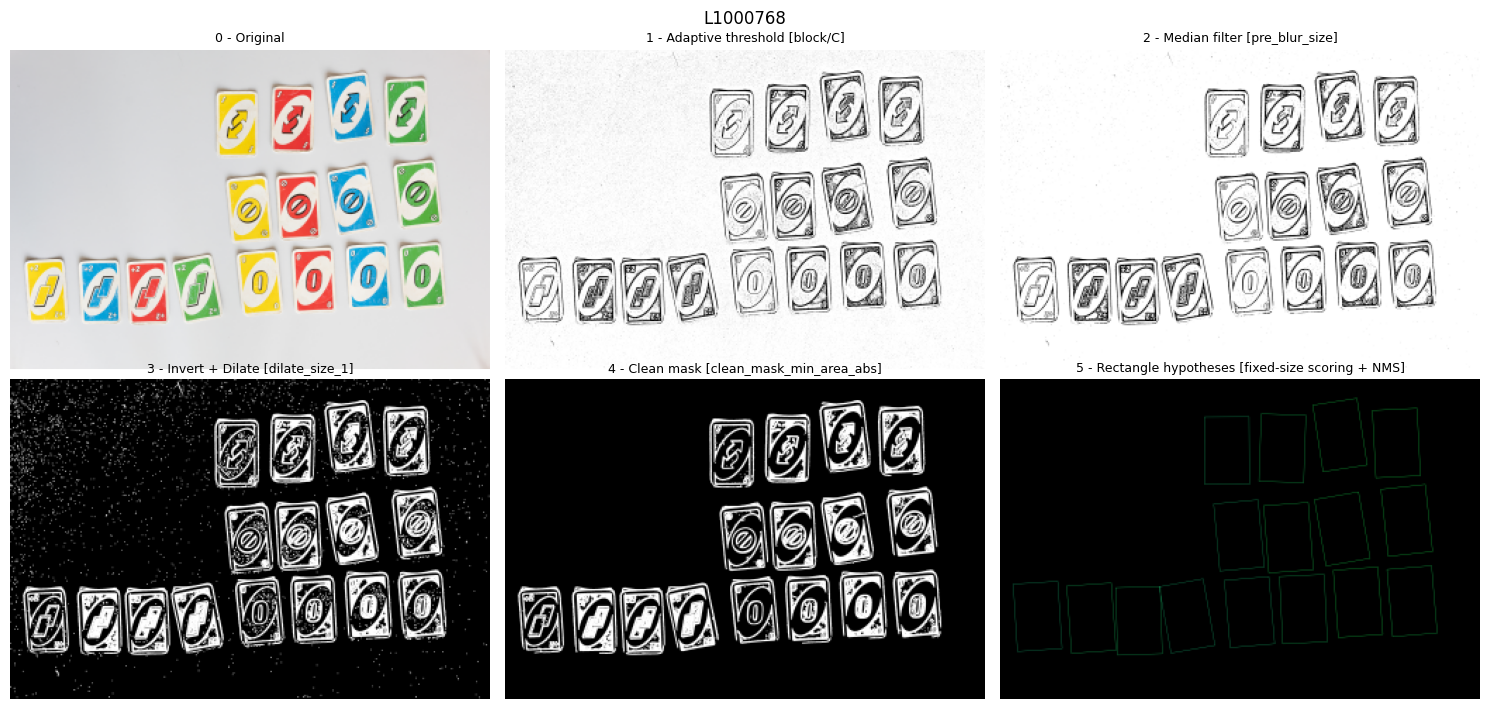

In [5]:
plot_pipeline_steps(color_rgb, pipeline_steps, preview_image_name)

In [6]:
selected = list(image_components.keys()) if images_to_process is None else images_to_process

results: dict[str, object] = {}
for name in selected:
    r = extract_reference_card_assets(
        image_name=name,
        num_components=image_components[name],
        **pipeline_kwargs,
        **extract_kwargs,
    )
    results[name] = r
    print(f"{name}: {len(r.components)} components, {len(r.masks)} masks, {len(r.crops)} crops")


L1000765: 12 components, 12 masks, 12 crops
L1000766: 12 components, 12 masks, 12 crops
L1000767: 14 components, 14 masks, 14 crops
L1000768: 16 components, 16 masks, 16 crops


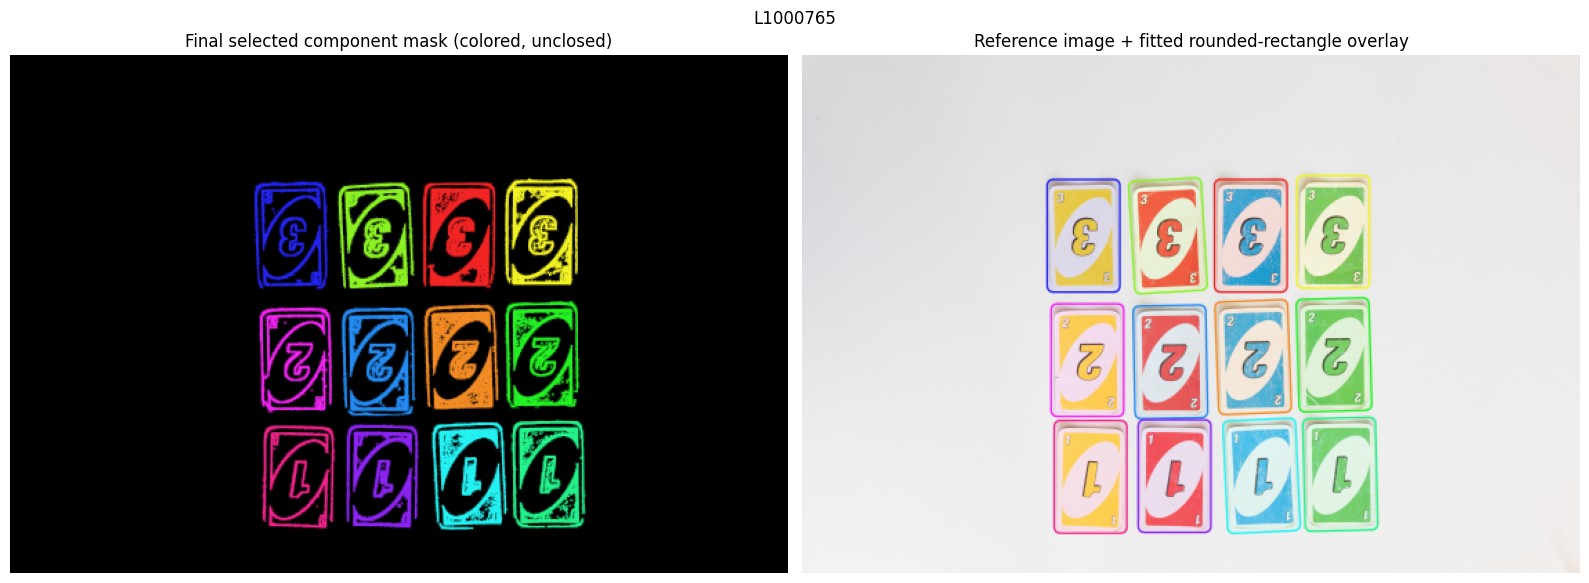

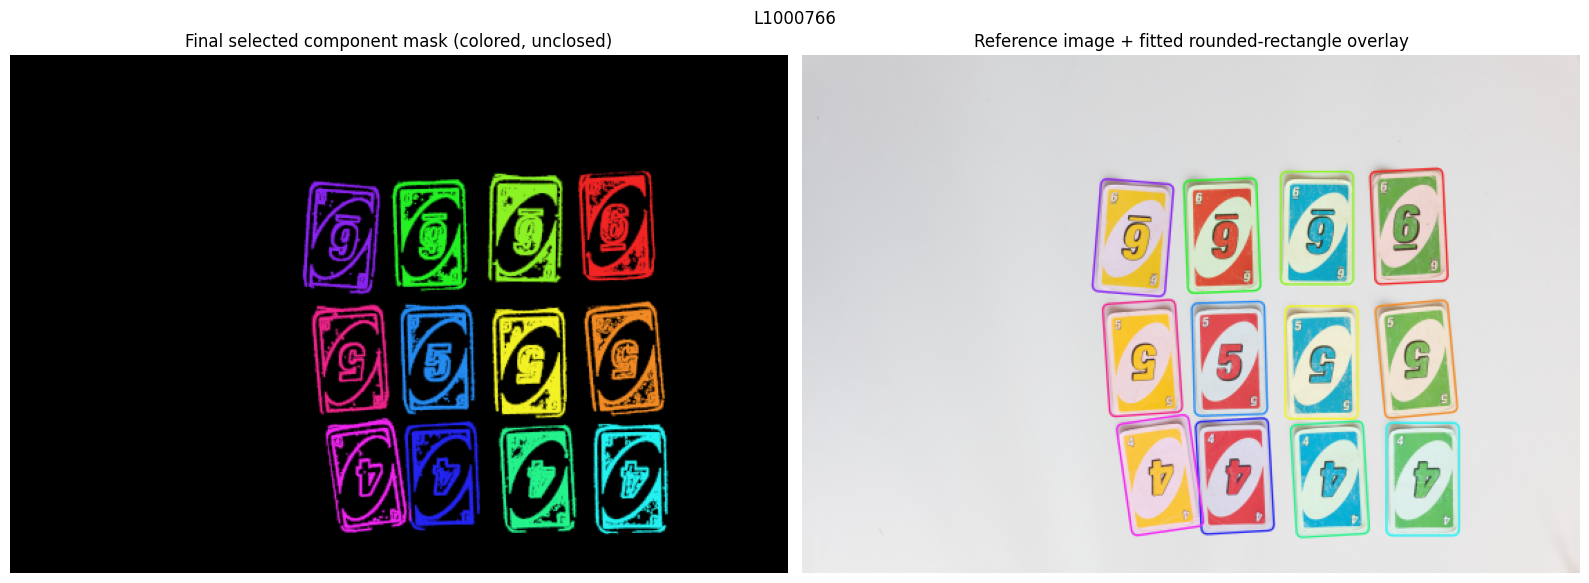

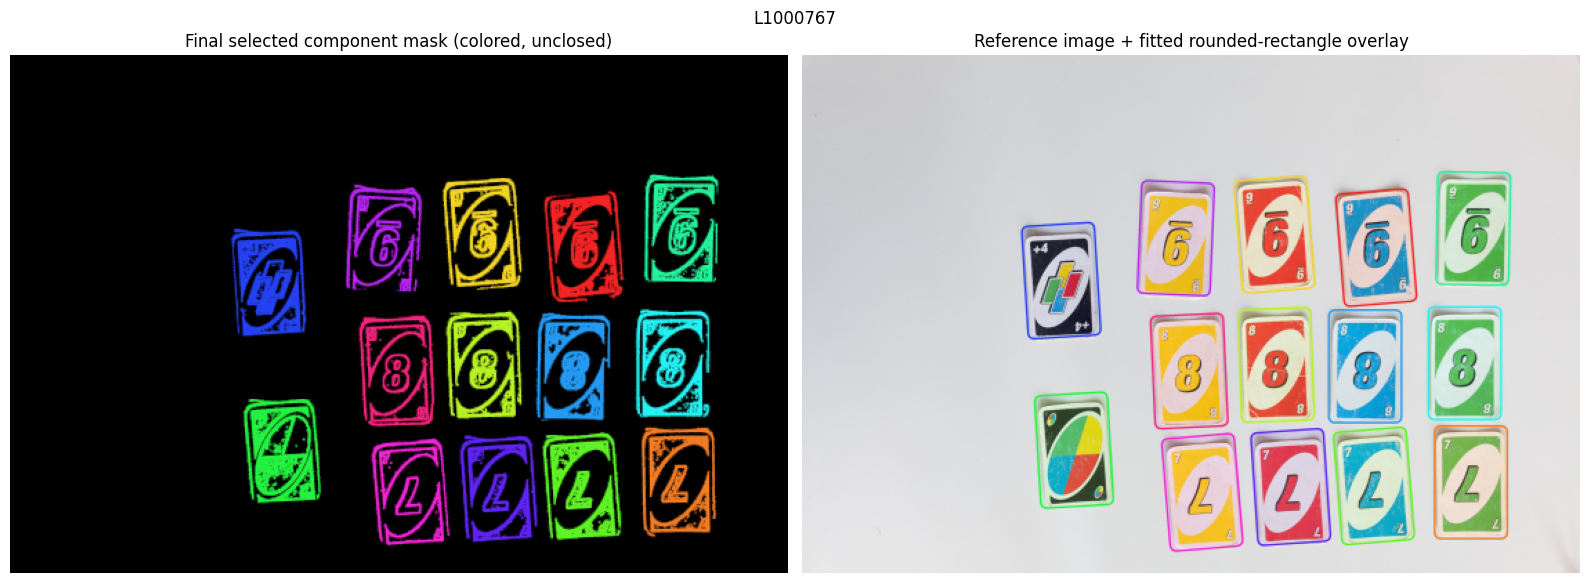

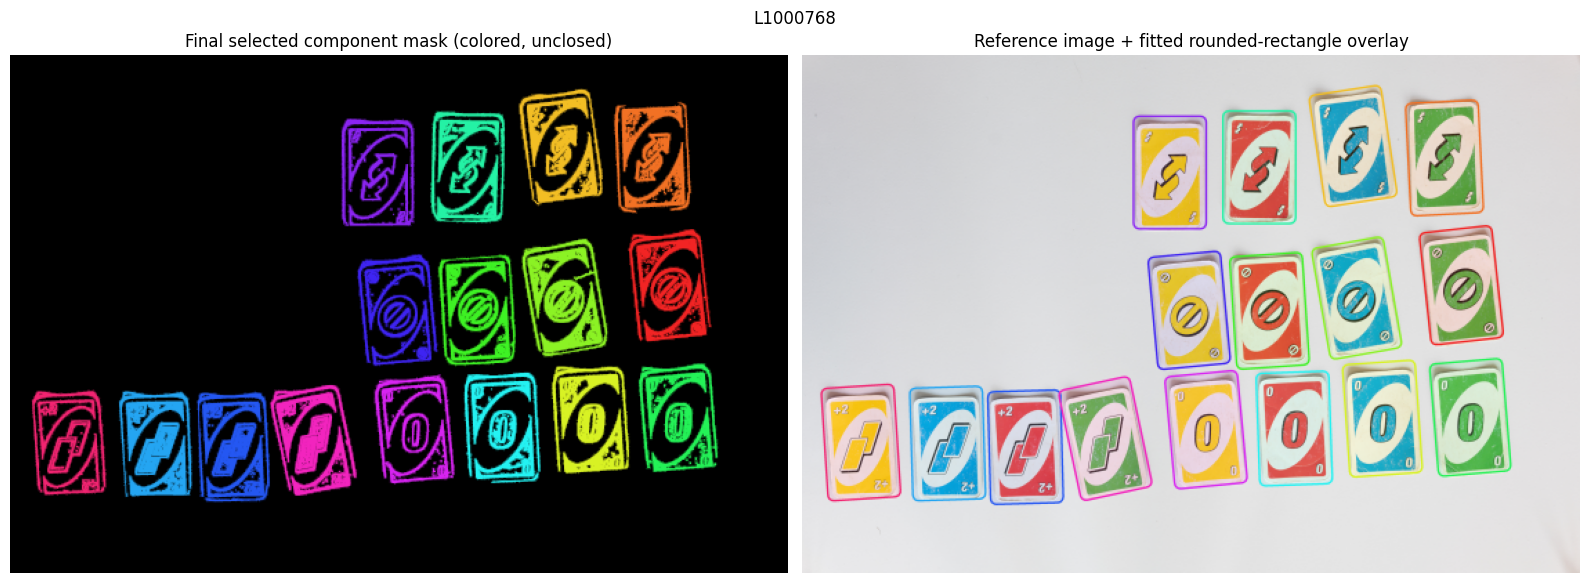

In [7]:
for name, result in results.items():
    plot_crop_preview(
        result,
        title=name,
        rounded_corner_ratio=rounded_corner_ratio,
        fixed_card_width=fixed_card_width,
        fixed_card_height=fixed_card_height,
    )
